## Feature Engineering Demos

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

insurance_df = pd.read_csv("../Data/insurance.csv")

insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [38]:
insurance_df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [37]:
def value_counter(dataframe):
    value_series = pd.DataFrame()
    for col in dataframe.select_dtypes(["object"]).columns:
        print(dataframe[col].value_counts())
             
value_counter(insurance_df)

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


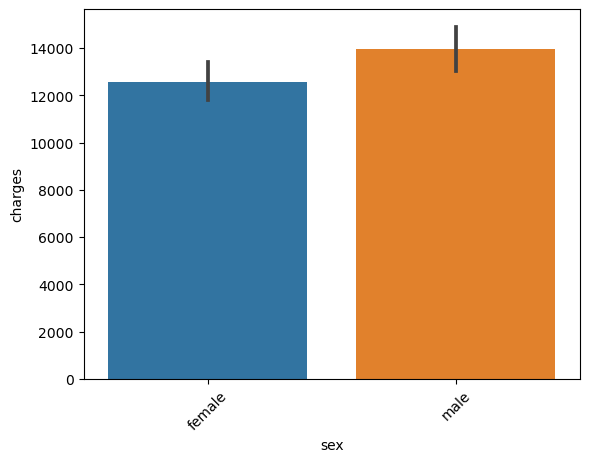

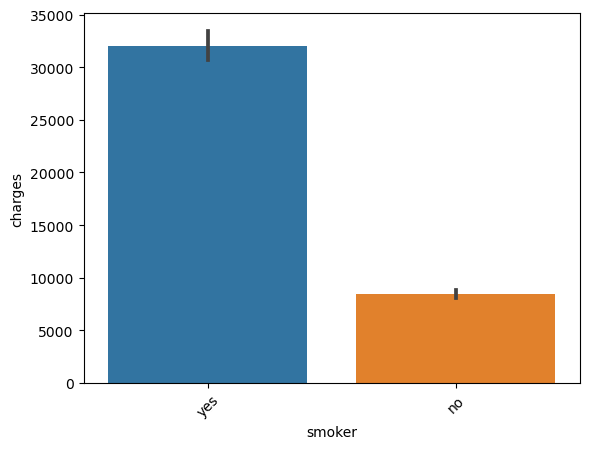

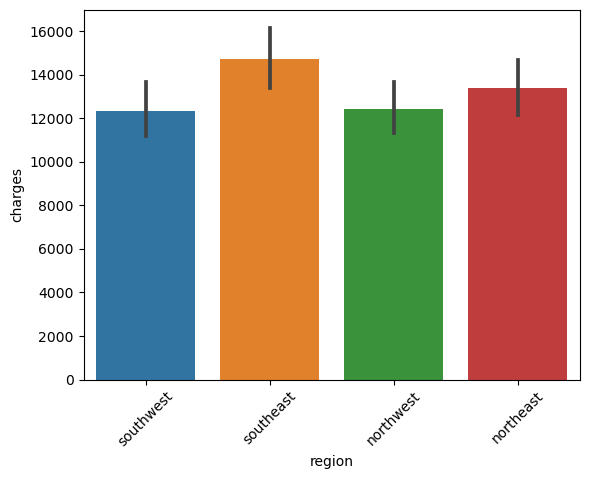

In [23]:
def cat_plotter(data, target):
    import matplotlib.pyplot as plt
    for col in data.select_dtypes(["object"]).columns:
        sns.barplot(data=data, x=col, y=target)
        plt.xticks(rotation=45)
        plt.show()
        
cat_plotter(insurance_df, "charges")

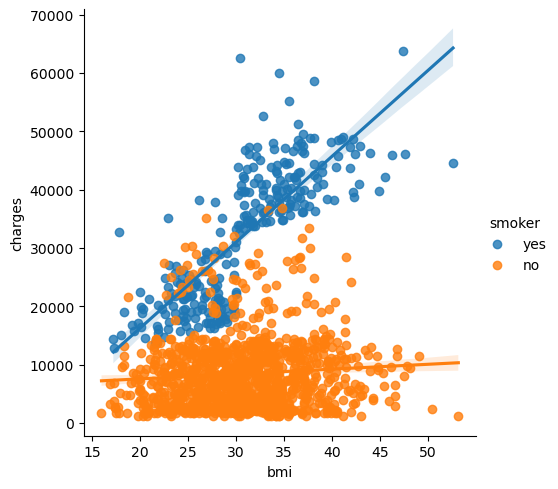

In [24]:
sns.lmplot(insurance_df, x="bmi", y="charges", hue="smoker")

In [39]:
region_dict = {
    "northwest": "west",
    "southwest": "west",
    "northeast": "east",
    "southeast": "east",
}

insurance_df["region_group"] = insurance_df["region"].map(region_dict)

insurance_df["region_group"].value_counts()

region_group
east    688
west    650
Name: count, dtype: int64

In [42]:
insurance_df["has_child"] = np.where(insurance_df["children"] > 0, 1, 0)

insurance_df["has_child"].value_counts()

has_child
1    764
0    574
Name: count, dtype: int64

In [41]:
insurance_df = insurance_df.drop(["region", "sex"], axis=1)

In [43]:
insurance_df.head()

,age,bmi,children,smoker,charges,region_group,has_child
0,19,27.900,0,yes,16884.92400,west,0
1,18,33.770,1,no,1725.55230,east,1
2,28,33.000,3,no,4449.46200,east,1
3,33,22.705,0,no,21984.47061,west,0
4,32,28.880,0,no,3866.85520,west,0


In [49]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

insurance_df = (
    pd.get_dummies(insurance_df, drop_first=True)
    .assign(
        age_sq=lambda x: x["age"] ** 2,
        smoker_bmi_int=lambda x: x["smoker_yes"] * x["bmi"]
    )
)

features = [
    #"age",
    "age_sq",
    "bmi",
    "children",
    #"smoker_yes",
    "smoker_bmi_int"
]

X = sm.add_constant(insurance_df[features])
y = insurance_df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2023
)

X_train.head()

,const,age_sq,bmi,children,smoker_bmi_int
1068,1.0,3969,21.660,1,0.0
1018,1.0,2916,35.815,3,0.0
995,1.0,1521,23.275,3,0.0
1248,1.0,324,39.820,0,0.0
549,1.0,1849,46.200,0,46.2


1068    14349.85440
1018    12495.29085
995      7986.47525
1248     1633.96180
549     45863.20500
           ...     
884      4877.98105
515     11362.75500
695      3201.24515
454      4686.38870
855      1875.34400
Name: charges, Length: 1070, dtype: float64

In [51]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=2023)

# 1) Užtikrina skaitinius tipus (object -> float)
X_num = X.apply(pd.to_numeric, errors="coerce")
y_num = pd.to_numeric(y, errors="coerce")

# 2) Pašalina eilutes su NaN (jei atsirado po konvertavimo)
mask = X_num.notna().all(axis=1) & y_num.notna()
X_values = X_num.loc[mask].to_numpy(dtype=float)
y_values = y_num.loc[mask].to_numpy(dtype=float)

cv_lm_r2s = []
cv_lm_maes = []

for train_ind, val_ind in kf.split(X_values, y_values):
    X_train, y_train = X_values[train_ind], y_values[train_ind]
    X_val, y_val = X_values[val_ind], y_values[val_ind]

    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_val)

    cv_lm_r2s.append(r2_score(y_val, y_pred))
    cv_lm_maes.append(mean_absolute_error(y_val, y_pred))

print("All Validation R2s: ", [round(x, 3) for x in cv_lm_r2s])
print(f"Cross Val R2s: {round(np.mean(cv_lm_r2s), 3)} +- {round(np.std(cv_lm_r2s), 3)}")

print("All Validation MAEs: ", [round(x, 3) for x in cv_lm_maes])
print(f"Cross Val MAEs: {round(np.mean(cv_lm_maes), 3)} +- {round(np.std(cv_lm_maes), 3)}")


All Validation R2s:  [0.829, 0.819, 0.814, 0.84, 0.811]
Cross Val R2s: 0.823 +- 0.011
All Validation MAEs:  [3013.519, 3222.757, 3268.545, 2972.638, 2995.334]
Cross Val MAEs: 3094.558 +- 124.887


Modelis įvertintas naudojant 5 kartų kryžminę validaciją.

Vidutinis R² = 0.84 ± 0.01 rodo, kad modelis paaiškina apie 84% kintamojo „charges“ variacijos. Maža standartinė paklaida reiškia, kad rezultatai tarp skirtingų fold’ų yra stabilūs.

Vidutinis MAE ≈ 2906 ± 126 reiškia, kad prognozės vidutiniškai klysta apie 2900 USD. Klaida tarp fold’ų nėra labai svyruojanti.

Išvada: modelis yra pakankamai stabilus ir prognozuoja gerai, tačiau praktiniame taikyme paklaida vis dar yra reikšminga.

In [52]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     1266.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:11:04   Log-Likelihood:                -10657.
No. Observations:                1071   AIC:                         2.132e+04
Df Residuals:                    1066   BIC:                         2.135e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2858.2878    817.363     -3.497      0.000   -4462.112   -1254.464
x1             3.3150      0.139     23.763      0.000       3.041       3.589
x2           154.7745     25.931      5.969      0.000     103.894     205.655
x3           567.2791    126.721      4.477      0.000     318.629     815.929
x4           796.9991     12.175     65.463      0.000     773.110     820.888
==============================================================================
Omnibus:                      442.672   Durbin-Watson:                   2.105
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1816.626
Skew:                           1.969   Prob(JB):                         0.00
Kurtosis:                       8.020   Cond. No.                     1.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [47]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1) Konvertuoja į skaitinius (jei kas liko object -> NaN)
X_train_num = X.apply(pd.to_numeric, errors="coerce")
y_train_num = pd.to_numeric(y, errors="coerce")

X_test_num  = X_test.apply(pd.to_numeric, errors="coerce")
y_test_num  = pd.to_numeric(y_test, errors="coerce")

# 2) Išmeta NaN eilutes (jei atsirado po konvertavimo)
mask_train = X_train_num.notna().all(axis=1) & y_train_num.notna()
mask_test  = X_test_num.notna().all(axis=1) & y_test_num.notna()

X_train_final = X_train_num.loc[mask_train].to_numpy(dtype=float)
y_train_final = y_train_num.loc[mask_train].to_numpy(dtype=float)

X_test_final  = X_test_num.loc[mask_test].to_numpy(dtype=float)
y_test_final  = y_test_num.loc[mask_test].to_numpy(dtype=float)

# 3) Fit + predict
model = sm.OLS(y_train_final, X_train_final).fit()
y_pred = model.predict(X_test_final)

print(f"Test R2: {r2_score(y_test_final, y_pred)}")
print(f"Test MAE: {mean_absolute_error(y_test_final, y_pred)}")


Test R2: 0.8442277808522045
Test MAE: 2909.8284400127477


In [53]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     1266.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:11:21   Log-Likelihood:                -10657.
No. Observations:                1071   AIC:                         2.132e+04
Df Residuals:                    1066   BIC:                         2.135e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2858.2878    817.363     -3.497      0.000   -4462.112   -1254.464
x1             3.3150      0.139     23.763      0.000       3.041       3.589
x2           154.7745     25.931      5.969      0.000     103.894     205.655
x3           567.2791    126.721      4.477      0.000     318.629     815.929
x4           796.9991     12.175     65.463      0.000     773.110     820.888
==============================================================================
Omnibus:                      442.672   Durbin-Watson:                   2.105
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1816.626
Skew:                           1.969   Prob(JB):                         0.00
Kurtosis:                       8.020   Cond. No.                     1.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Šiame kode prieš modelio treniravimą atliekamas duomenų paruošimas, kad OLS modelis gautų tik skaitinius ir tvarkingus duomenis.

X.apply(pd.to_numeric, errors="coerce") ir pd.to_numeric(y, errors="coerce") užtikrina, kad visi stulpeliai būtų skaitiniai. Jei randamos ne skaitinės reikšmės, jos paverčiamos į NaN. Tai svarbu, nes statsmodels OLS negali dirbti su object tipo duomenimis.

mask = ...notna()... naudojamas tam, kad būtų pašalintos eilutės su NaN reikšmėmis. Modelis negali būti treniruojamas su trūkstamomis reikšmėmis.

.loc[mask] leidžia atrinkti tik tas eilutes, kurios atitinka sąlygą (t. y. neturi NaN). Tai saugus būdas filtruoti duomenis pagal loginę kaukę.

.to_numpy(dtype=float) paverčia DataFrame į gryną NumPy masyvą su float tipu. Statsmodels OLS veikia stabiliau, kai gauna aiškiai apibrėžtą skaitinį masyvą.

Po šių žingsnių modelis treniruojamas (fit) su švariais duomenimis ir atliekama prognozė testavimo rinkinyje.

Test R² = 0.844 reiškia, kad modelis paaiškina apie 84.4% „charges“ variacijos testavimo duomenyse. Tai rodo gerą prognozavimo gebėjimą ir panašų rezultatą kaip kryžminėje validacijoje.

Test MAE ≈ 2910 reiškia, kad prognozės vidutiniškai klysta apie 2900 piniginių vienetų. 

Kadangi testavimo rezultatai yra labai artimi Cross-Validation rezultatams, modelis greičiausiai nėra perfitintas ir gerai generalizuoja naujiems duomenims.

In [31]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     1177.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:22:05   Log-Likelihood:                -13246.
No. Observations:                1338   AIC:                         2.651e+04
Df Residuals:                    1331   BIC:                         2.654e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2343.6991   1372.084      1.708      0.088    -347.983    5035.381
x1           -32.2109     64.921     -0.496      0.620    -159.570      95.148
x2             3.7471      0.810      4.627      0.000       2.158       5.336
x3             2.4936     24.694      0.101      0.920     -45.950      50.937
x4           667.5636    115.007      5.805      0.000     441.949     893.178
x5         -2.012e+04   1642.054    -12.253      0.000   -2.33e+04   -1.69e+04
x6          1431.6963     52.424     27.310      0.000    1328.853    1534.540
==============================================================================
Omnibus:                      732.227   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4630.947
Skew:                           2.567   Prob(JB):                         0.00
Kurtosis:                      10.531   Cond. No.                     2.70e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.7e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

 **OLS regresijos modelio santrauka (model.summary())** iš `statsmodels`.

Trumpai, ką rodo pagrindinės dalys:

**Viršuje – modelio kokybė**

* R-squared = 0.841 → modelis paaiškina ~84% variacijos.
* Adj. R-squared = 0.841 → pakoreguotas R² (atsižvelgia į kintamųjų skaičių).
* F-statistic + Prob(F-statistic)=0.00 → modelis kaip visuma yra statistiškai reikšmingas.

**Viduryje – koeficientų lentelė**

* coef → koeficiento dydis (kiek keičiasi y, kai x padidėja 1 vienetu).
* std err → standartinė paklaida.
* t → t-statistika.
* P>|t| → p-reikšmė (ar kintamasis reikšmingas).
* [0.025, 0.975] → 95% pasikliautinas intervalas.

Jei p < 0.05 → kintamasis statistiškai reikšmingas.
Pvz. x2, x4, x5, x6 yra reikšmingi, o x1 ir x3 – nereikšmingi.

**Apačioje – diagnostika**

* Durbin-Watson ≈ 2.08 → nėra aiškios autokoreliacijos.
* Omnibus / Jarque-Bera → rodo, kad liekanos nėra normaliai pasiskirsčiusios.
* Cond. No. = 2.7e+04 → gali būti multikolinearumo ar mastelio problemų.


In [32]:
from sklearn.model_selection import train_test_split


insurance_df = (
    pd.get_dummies(insurance_df, drop_first=True)
    .assign(
        age_sq = insurance_df["age"]**2,
       smoker_bmi_int = lambda x: x["smoker_yes"] * x["bmi"]
           )
)

features = ["age",
            "age_sq"
             "bmi", 
             "children", 
             "smoker_flag",
            "smoker_bmi_int" ]

X = sm.add_constant(insurance_df.drop(["charges"], axis=1))
y = insurance_df["charges"]

X, X_test, y, y_test = train_test_split(X, y, test_size=.2, random_state=2023)

X.head()

,const,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_sq,smoker_bmi_int
1068,1.0,63,21.660,1,True,False,True,False,False,3969,0.0
1018,1.0,54,35.815,3,False,False,True,False,False,2916,0.0
995,1.0,39,23.275,3,False,False,False,False,False,1521,0.0
1248,1.0,18,39.820,0,False,False,False,True,False,324,0.0
549,1.0,43,46.200,0,False,True,False,True,False,1849,46.2


In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Dummy + feature engineering
df = (
    pd.get_dummies(insurance_df, drop_first=True)
    .assign(
        age_sq=lambda x: x["age"] ** 2,
        smoker_bmi_int=lambda x: x["smoker_yes"] * x["bmi"]
    )
)

features = ["age", "age_sq", "bmi", "children", "smoker_yes", "smoker_bmi_int"]

# 2) X, y (dar be const)
X = df[features].copy()
y = df["charges"].copy()

# 3) Priverstinai į skaitinius (kad neliktų object/bool)
X = X.apply(pd.to_numeric, errors="coerce").astype(float)
y = pd.to_numeric(y, errors="coerce").astype(float)

# 4) Pašalinti NaN dar prieš split (paprasčiau ir saugiau)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

# 5) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2023
)

# 6) Pridėti const PO split
X_train = sm.add_constant(X_train, has_constant="add")
X_test  = sm.add_constant(X_test, has_constant="add")

# 7) Dar kartą priverstinai į float (ypač const)
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

# 8) OLS fit + test metrikos
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

y_pred = model.predict(X_test)
print(f"Test R2: {r2_score(y_test, y_pred)}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred)}")

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     935.7
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:33:29   Log-Likelihood:                -10608.
No. Observations:                1070   AIC:                         2.123e+04
Df Residuals:                    1063   BIC:                         2.126e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           2525.4807   1563.554      1.

Modelis paaiškina apie 84% „charges“ variacijos (R² = 0.841, Adj. R² = 0.840). 
F-statistic p-reikšmė = 0.00 rodo, kad modelis kaip visuma yra statistiškai reikšmingas.

Reikšmingi kintamieji (p < 0.05):
- age_sq – teigiamas efektas: su amžiumi išlaidos didėja pagreitėjančiu tempu (kvadratinis ryšys).
- children – kiekvienas papildomas vaikas didina išlaidas vidutiniškai apie 690.
- smoker_yes ir smoker_bmi_int – labai stiprus poveikis. Rūkymo efektas priklauso nuo BMI: kuo didesnis BMI, tuo didesnės išlaidos rūkantiems.

Nereikšmingi kintamieji:
- age (linijinė dalis)
- bmi (bazinis efektas be sąveikos)
- const

Testavimo rezultatai (R² ≈ 0.844, MAE ≈ 2900) yra labai panašūs į treniravimo rezultatus, todėl modelis gerai generalizuoja ir nėra akivaizdaus perfitinimo.

Diagnostika:
- Durbin-Watson ≈ 2 → nėra aiškios autokoreliacijos.
- Omnibus / Jarque-Bera rodo, kad liekanos nėra normalios.
- Didelis Condition Number (2.7e+04) gali rodyti multikolinearumo ar mastelio problemą (ypač dėl age ir age_sq).